# AIM · 1주차 자율 과제
## CNN ① 이미지에서 패턴 찾기

**대상:** Python·PyTorch 기초 이수자 / **권장:** Google Colab Python 3, GPU 선택 가능.

Python, 텐서, nn.Module, 역전파 기초를 전제로 한다. FashionMNIST 다운로드를 수업 전에 완료한다. 실습 기본값은 일부 학습 데이터와 짧은 학습이며 목표는 최고 정확도보다 올바른 파이프라인이다.

### 학습 목표
- 합성곱의 출력 크기와 파라미터 수를 계산한다.
- FashionMNIST 분류기를 구현하고 학습을 진단한다.
- 특징 맵과 오분류를 근거로 모델의 한계를 설명한다.

### 실행 방법
1. Colab에서 `파일 → 노트북 업로드`로 이 파일을 엽니다.
2. GPU를 사용할 경우 `런타임 → 런타임 유형 변경`에서 GPU를 선택합니다.
3. 위에서 아래로 셀을 실행합니다. 이전 주차 파일이나 별도 Python 모듈은 필요 없습니다.
4. Colab 기본 torch·torchvision을 우선 사용합니다. import가 실패하면 새 런타임에서 시작하세요.
   로컬 환경은 루트 `환경설정.md`를 참고하세요. 데이터 최초 다운로드에는 인터넷이 필요합니다.
5. 학습이 길면 `TRAIN_N`, `EPOCHS` 또는 `STEPS`를 줄입니다. 작은 실험의 품질은 보장되지 않습니다.

**시간 운영:** 실습 셀 번호가 아니라 아래 § 구간으로 진행합니다. 준비·다운로드는 수업 시작에,
핵심 실행은 50–75분에, 관찰 답변은 75–85분에 수행합니다. 심화와 자율 과제는 수업 밖에서 진행합니다.

**재현성:** 고정 seed도 다른 GPU·라이브러리 버전의 완전히 같은 수치를 보장하지 않습니다.
실제 출력과 예측을 구분해 기록하세요. `outputs/`는 현재 실행 폴더에 생성됩니다.

### 자율 과제 안내

**A·B 기본 / C 비교 실험 / D 도전**입니다. 모두 선택이며 전부 하면 약 80–130분과 학습 시간이 필요합니다.
한 문제만 골라도 괜찮습니다. 이 노트북은 실습 파일 실행 없이 독립적으로 시작할 수 있습니다.

준비 코드는 제공하고, 아래 TODO 함수에 직접 구현합니다. 미완성 상태의 `return None`은 실행을 중단하지 않고 안내만 출력합니다.
코드를 작성하면 바로 다음 검사 셀을 실행하세요. 검사는 최소 계약만 확인하며 좋은 실험 해석을 자동 채점하지 않습니다.

**제출을 선택한다면:** 실행 결과가 남은 ipynb, 비교 표·그림, 아래 해석 5문장을 저장하세요.
test로 과제 조건을 반복 선택하지 말고 validation을 사용하세요.

## §1 · 환경 확인

첫 실행에서 버전과 device를 확인합니다. CPU도 지원하며 설치가 필요한 경우 환경설정 문서를 먼저 읽습니다.

In [1]:
import os, sys, math, random, copy, time, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
from IPython.display import display

SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# QUICK=True: 수업용 일부 데이터. False: 데이터/학습 예산 확대.
QUICK = True
# 검증 제작자용 축소 모드. 수강생은 설정할 필요가 없습니다.
SMOKE = os.environ.get('AIM_SMOKE', '0') == '1'
DATA_ROOT = Path(os.environ.get('AIM_DATA_ROOT', './data'))
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
torch.set_num_threads(min(4, os.cpu_count() or 1))

def seed_all(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_all()
print('Python', sys.version.split()[0], '| torch', torch.__version__,
      '| torchvision', torchvision.__version__, '| device', DEVICE)
print('QUICK:', QUICK, '| SMOKE:', SMOKE, '| data:', DATA_ROOT.resolve())

def image_grid(images, titles=None, cols=8, title='', normalized=False):
    images = images.detach().cpu()
    if normalized: images = (images * .5 + .5).clamp(0, 1)
    n = len(images); rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.35, rows*1.55), squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i < n:
            im = images[i]
            ax.imshow(im.squeeze(0) if im.shape[0]==1 else im.permute(1,2,0),
                      cmap='gray', vmin=0, vmax=1)
            if titles is not None: ax.set_title(str(titles[i]), fontsize=8)
    fig.suptitle(title); fig.tight_layout(); plt.show()
    return fig

def num_params(model): return sum(p.numel() for p in model.parameters() if p.requires_grad)

def cpu_state(model):
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

Python 3.13.9 | torch 2.14.0+cpu | torchvision 0.29.0+cpu | device cpu
QUICK: True | SMOKE: False | data: D:\AIM\.study-data


In [2]:
DATASET = 'fashion'
TRAIN_N = 256 if SMOKE else (4096 if QUICK else 40000)
VAL_N = 128 if SMOKE else (1024 if QUICK else 5000)
TEST_N = 128 if SMOKE else (1024 if QUICK else 10000)
BATCH = 64 if SMOKE else 128
EPOCHS = 1 if SMOKE else (3 if QUICK else 15)

## §2 · 데이터와 분할

공식 train을 고정 인덱스로 나누고 test는 마지막에만 사용합니다. QUICK의 평가 숫자는 전체 공식 test의 성능이 아닌 고정 부분집합 성능입니다. MNIST 계열은 0~1, CIFAR10만 -1~1로 변환합니다.

100%|██████████| 26.4M/26.4M [00:15<00:00, 1.70MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 108kB/s]
100%|██████████| 4.42M/4.42M [00:07<00:00, 578kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 30.4MB/s]


split sizes: 4096 1024 1024
shape: torch.Size([128, 1, 28, 28]) dtype: torch.float32 range: (0.0, 1.0)


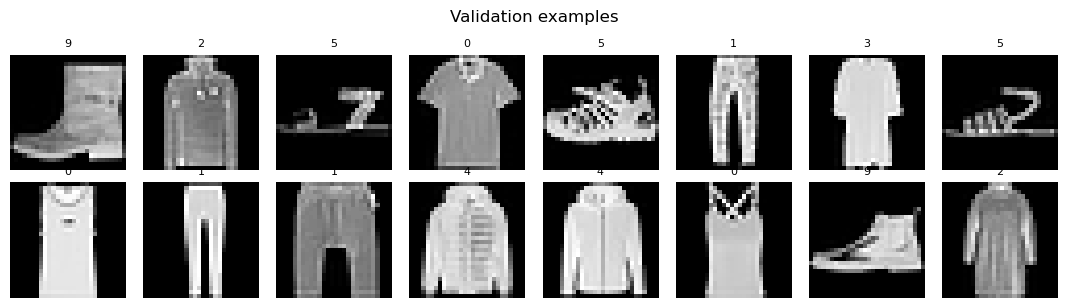

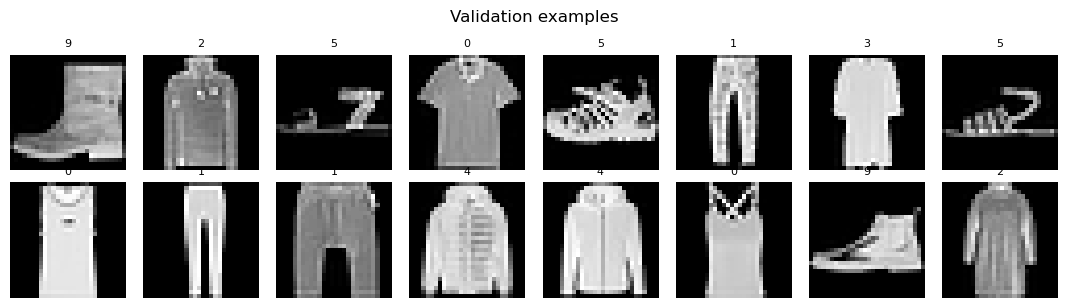

In [3]:
# DATASET은 앞의 설정 셀에서 지정합니다.train/valは公式trainから分割。
def vision_loaders(name, augment=False):
    cls = {'fashion':datasets.FashionMNIST, 'cifar':datasets.CIFAR10, 'mnist':datasets.MNIST}[name]
    base = [transforms.ToTensor()]
    if name=='cifar': base += [transforms.Normalize((.5,)*3, (.5,)*3)]
    eval_tf = transforms.Compose(base)
    train_tf = transforms.Compose(([transforms.RandomCrop(32,padding=4),
                                    transforms.RandomHorizontalFlip()] if augment else []) + base)
    train_ds = cls(DATA_ROOT, train=True, download=True, transform=train_tf)
    val_ds = cls(DATA_ROOT, train=True, download=True, transform=eval_tf)
    test_ds = cls(DATA_ROOT, train=False, download=True, transform=eval_tf)
    ids = torch.randperm(len(train_ds), generator=torch.Generator().manual_seed(SEED))
    n_val = 5000 if name=='cifar' else 6000
    train_ids = ids[n_val:][:TRAIN_N].tolist()
    val_ids = ids[:n_val][:VAL_N].tolist()
    test_ids = torch.randperm(len(test_ds), generator=torch.Generator().manual_seed(SEED+1))[:TEST_N].tolist()
    assert not (set(train_ids) & set(val_ids))
    train = DataLoader(Subset(train_ds,train_ids), batch_size=BATCH, shuffle=True,
                       generator=torch.Generator().manual_seed(SEED), num_workers=0)
    val = DataLoader(Subset(val_ds,val_ids), batch_size=BATCH, shuffle=False, num_workers=0)
    test = DataLoader(Subset(test_ds,test_ids), batch_size=BATCH, shuffle=False, num_workers=0)
    return train,val,test

train_loader, val_loader, test_loader = vision_loaders(DATASET)
xb,yb = next(iter(val_loader))
print('split sizes:', *(len(dl.dataset) for dl in [train_loader,val_loader,test_loader]))
print('shape:', xb.shape, 'dtype:', xb.dtype, 'range:', (xb.min().item(),xb.max().item()))
image_grid(xb[:16], yb[:16].tolist(), title='Validation examples', normalized=DATASET=='cifar')

## §3 · 분류 모델 정의

모델 코드의 각 층 옆에 입출력 shape를 손으로 적어 보세요. MLP/SmallCNN은 FashionMNIST용, CifarCNN은 컬러 이미지용입니다.

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(),nn.Linear(784,128),nn.ReLU(),nn.Linear(128,10))
    def forward(self,x): return self.net(x)

class SmallCNN(nn.Module):
    def __init__(self,width=16,kernel=3):
        super().__init__()
        assert kernel % 2 == 1
        self.features=nn.Sequential(
            nn.Conv2d(1,width,kernel,padding=kernel//2),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(width,width*2,kernel,padding=kernel//2),nn.ReLU(),nn.MaxPool2d(2))
        self.classifier=nn.Sequential(nn.Flatten(),nn.Linear(width*2*7*7,64),nn.ReLU(),nn.Linear(64,10))
    def forward(self,x): return self.classifier(self.features(x))

class ResidualBlock(nn.Module):
    def __init__(self,cin,cout,stride=1):
        super().__init__()
        self.body=nn.Sequential(nn.Conv2d(cin,cout,3,stride,1,bias=False),nn.BatchNorm2d(cout),nn.ReLU(),
                                nn.Conv2d(cout,cout,3,1,1,bias=False),nn.BatchNorm2d(cout))
        self.skip=nn.Identity() if cin==cout and stride==1 else nn.Sequential(
            nn.Conv2d(cin,cout,1,stride,bias=False),nn.BatchNorm2d(cout))
    def forward(self,x): return F.relu(self.body(x)+self.skip(x))

class CifarCNN(nn.Module):
    def __init__(self,residual=False):
        super().__init__()
        layers=[nn.Conv2d(3,32,3,padding=1,bias=False),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2)]
        if residual: layers += [ResidualBlock(32,64,stride=2)]
        else: layers += [nn.Conv2d(32,64,3,padding=1,bias=False),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2)]
        self.features=nn.Sequential(*layers,nn.AdaptiveAvgPool2d(1))
        self.head=nn.Linear(64,10)
    def forward(self,x): return self.head(self.features(x).flatten(1))

## §4 · 공통 학습·평가 함수

샘플 수 가중 평균, eval/no_grad, 최고 validation checkpoint 복사를 확인합니다.

In [5]:
def classification_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training); total=correct=count=0
    all_y=[]; all_pred=[]
    with torch.set_grad_enabled(training):
        for x,y in loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            if training: optimizer.zero_grad(set_to_none=True)
            logits=model(x); loss=F.cross_entropy(logits,y)
            assert torch.isfinite(loss), 'loss is not finite'
            if training: loss.backward(); optimizer.step()
            n=len(y); total+=loss.item()*n; count+=n
            pred=logits.argmax(1); correct+=(pred==y).sum().item()
            all_y.append(y.detach().cpu()); all_pred.append(pred.detach().cpu())
    return dict(loss=total/count,accuracy=correct/count,
                y=torch.cat(all_y),pred=torch.cat(all_pred))

def fit_classifier(factory,loader,epochs=EPOCHS):
    seed_all(); model=factory().to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)
    history=[]; best_loss=float('inf'); best=None; start=time.perf_counter()
    for ep in range(epochs):
        tr=classification_epoch(model,loader,opt); va=classification_epoch(model,val_loader)
        history.append(dict(epoch=ep+1,train_loss=tr['loss'],val_loss=va['loss'],val_acc=va['accuracy']))
        if va['loss']<best_loss: best_loss=va['loss']; best=cpu_state(model)
        print(f"epoch {ep+1}: train={tr['loss']:.3f} val={va['loss']:.3f} acc={va['accuracy']:.3f}")
    model.load_state_dict(best)
    return model,history,time.perf_counter()-start

def plot_classification(histories):
    fig,axes=plt.subplots(1,2,figsize=(10,3))
    for name,h in histories.items():
        axes[0].plot([r['epoch'] for r in h],[r['train_loss'] for r in h],label=name+' train')
        axes[0].plot([r['epoch'] for r in h],[r['val_loss'] for r in h],'--',label=name+' val')
        axes[1].plot([r['epoch'] for r in h],[r['val_acc'] for r in h],label=name)
    axes[0].set_title('Cross entropy'); axes[1].set_title('Validation accuracy')
    for ax in axes: ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=.2)
    plt.tight_layout(); plt.show()

def confusion(y,pred,nclass=10):
    return torch.bincount(y*nclass+pred,minlength=nclass*nclass).reshape(nclass,nclass)

def inspect_classifier(model):
    result=classification_epoch(model,val_loader)
    cm=confusion(result['y'],result['pred'])
    fig,ax=plt.subplots(figsize=(5,4)); im=ax.imshow(cm,cmap='Blues')
    ax.set(xlabel='predicted',ylabel='true',xticks=range(10),yticks=range(10))
    fig.colorbar(im,ax=ax); plt.show()
    recall=cm.diag().float()/cm.sum(1).clamp_min(1)
    print('class counts:',cm.sum(1).tolist()); print('recall:',recall.tolist())
    wrong=(result['y']!=result['pred']).nonzero().flatten()[:8]
    if len(wrong):
        imgs=torch.stack([val_loader.dataset[i.item()][0] for i in wrong])
        labels=[f"true={result['y'][i]} pred={result['pred'][i]}" for i in wrong]
        image_grid(imgs,labels,title='Validation errors',normalized=DATASET=='cifar')
    else: print('No error in this validation subset; inspect a larger subset.')
    return cm

## A · 출력 크기 계산 / 10분

일반 Conv2d의 한 축 출력 크기를 반환하세요. dilation과 내림을 포함하고, 크기는 양수라고 가정합니다.

In [6]:
def conv_out(h,k,p=0,s=1,d=1):
    # TODO: 정수 출력 크기 반환
    return None

In [7]:
if conv_out(28,3,1) is None:
    print('미완성: A를 구현한 뒤 다시 검사하세요.')
else:
    assert conv_out(28,3,1)==28
    assert conv_out(32,3,0,2)==15
    assert conv_out(9,3,0,1,2)==5
    print('PASS A')

미완성: A를 구현한 뒤 다시 검사하세요.


**기록:** 구현한 식 또는 shape, 검사 결과, 아직 불확실한 점을 적으세요.

_여기에 작성_

## B · Conv 파라미터 수 / 10분

입출력 채널과 커널 크기로 파라미터 수를 계산하세요. groups와 bias=False를 지원하세요. 채널 수는 groups로 나누어 떨어진다고 가정합니다.

In [8]:
def conv_params(cin,cout,k,bias=True,groups=1):
    # TODO
    return None

In [9]:
if conv_params(3,8,3) is None:
    print('미완성: B를 구현하세요.')
else:
    assert conv_params(3,8,3)==224
    assert conv_params(4,8,3,False,2)==144
    for args in [(1,16,3,True,1),(4,8,3,False,2)]:
        ci,co,k,b,g=args
        assert conv_params(*args)==num_params(nn.Conv2d(ci,co,k,bias=b,groups=g))
    print('PASS B')

미완성: B를 구현하세요.


**기록:** 구현한 식 또는 shape, 검사 결과, 아직 불확실한 점을 적으세요.

_여기에 작성_

## C · 채널 폭 ablation / 30–45분

SmallCNN width=8과 width=16을 같은 초기 seed·분할·epoch로 학습하세요. 결과를 `width, params, val_loss, val_acc` 열의 리스트로 반환하세요. test는 사용하지 마세요.

In [10]:
def width_experiment():
    # TODO: fit_classifier와 classification_epoch 사용
    return None

In [11]:
width_rows=width_experiment()
if width_rows is None:
    print('미완성: C 실험을 작성하세요.')
else:
    assert len(width_rows)==2 and {r['width'] for r in width_rows}=={8,16}
    assert all(np.isfinite(r['val_loss']) and 0<=r['val_acc']<=1 for r in width_rows)
    assert width_rows[0]['params']<width_rows[1]['params']
    display(width_rows)

미완성: C 실험을 작성하세요.


**기록:** 구현한 식 또는 shape, 검사 결과, 아직 불확실한 점을 적으세요.

_여기에 작성_

## D · 이동 강건성 / 20–30분

학습된 SmallCNN의 입력을 오른쪽으로 1픽셀 이동시키고 왼쪽을 0으로 채우세요. torch.roll의 wrap-around는 사용하지 마세요. 원본 대비 예측 변경 비율을 반환하세요.

In [12]:
def shift_rate():
    # TODO: 새 CNN을 학습하고 validation에서 비교
    return None

In [13]:
rate=shift_rate()
if rate is None: print('미완성: D는 도전 과제입니다.')
else:
    assert 0<=rate<=1
    print('prediction change rate:',rate)

미완성: D는 도전 과제입니다.


**기록:** 구현한 식 또는 shape, 검사 결과, 아직 불확실한 점을 적으세요.

_여기에 작성_

## 비교 실험 해석 · 5문장 필수 틀

1. 나의 질문과 바꾼 변수는 …
2. 고정한 조건(분할, seed, 예산, 평가)은 …
3. 실제 관측 결과는 … (숫자·그림 번호를 근거로)
4. 이 결과만으로 말할 수 없는 것은 …
5. 다음에 한 가지만 더 검증한다면 …

| 조건 | seed | 학습 예산 | params | validation 지표 | 시간 | 관찰 |
|---|---|---|---|---|---|---|
| 기준 | | | | | | |
| 변경 | | | | | | |

### 자기 점검 기준 (100점 환산, 성적 부여 목적 아님)
- 구현의 shape·수식·gradient·mask 계약 30
- 통제 조건과 재현 가능한 코드 25
- 실제 결과 표·그림과 실패 사례 25
- 과장 없는 해석과 한계·후속 실험 20

고정 정확도나 생성 품질 기준은 없습니다. 개선되지 않은 실험도 근거를 잘 남기면 좋은 결과물입니다.